```text id="3gnlvh"
✅ 1. Project Setup & Imports
✅ 2. Load Config & LLM
✅ 3. Create Planner Node
✅ 4. Test Planner Node
✅ 5. Create Researcher Node
✅ 6. Test Researcher Node
✅ 7. Create Summarizer Node
✅ 8. Test Summarizer Node
✅ 9. Create StateGraph
✅ 10. Add All Nodes
✅ 11. Add Sequential Edges
✅ 12. Compile Graph
✅ 13. Invoke Graph
✅ 14. Visualize Workflow
✅ 15. Observe State Evolution
✅ 16. Final Recap
```

In [1]:
# ==========================================
# Notebook 2: Sequential Workflows
# Project Setup & Imports
# ==========================================

import os
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root Added Successfully")
print(PROJECT_ROOT)

Project Root Added Successfully
d:\projects\python\stepIntoAI\LangGraph-Crash-Course


In [2]:
# ==========================================
# Load Config, LLM & LangGraph Components
# ==========================================

from src.utils.config_loader import load_config
from src.utils.model_loader import load_llm

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END

from src.states.state_schema import GraphState

config = load_config()
llm = load_llm()

print("Configuration Loaded Successfully")
print("LLM Loaded Successfully")
print(type(llm))

Configuration Loaded Successfully
LLM Loaded Successfully
<class 'langchain_openai.chat_models.base.ChatOpenAI'>


In [3]:
# ==========================================
# Planner Node
# ==========================================

def planner_node(state: GraphState):

    print("\n--- Planner Node Executed ---")

    return {
        "keywords": [
            state["user_query"],
            "AI",
            "Research"
        ]
    }


print("Planner Node Created Successfully")

Planner Node Created Successfully


In [4]:
# ==========================================
# Researcher Node
# ==========================================

def researcher_node(state: GraphState):

    print("\n--- Researcher Node Executed ---")

    response = llm.invoke(
        f"""
        Write 5-6 lines about:
        {state['user_query']}
        
        Use the following keywords:
        {state['keywords']}
        """
    )

    return {
        "research_notes": response.content
    }


print("Researcher Node Created Successfully")

Researcher Node Created Successfully


In [5]:
# ==========================================
# Test Researcher Node
# ==========================================

test_state = {
    "user_query": "LangGraph",
    "keywords": ["LangGraph", "AI", "Research"]
}

result = researcher_node(test_state)

print("\nResearch Notes:\n")
print(result["research_notes"])


--- Researcher Node Executed ---

Research Notes:

LangGraph is an innovative platform that leverages AI to enhance research capabilities in the field of natural language processing. By integrating advanced algorithms, LangGraph enables researchers to analyze and visualize complex language data more effectively. This tool not only streamlines the research process but also fosters collaboration among scholars, allowing for the sharing of insights and findings. With its user-friendly interface, LangGraph is poised to become an essential resource for those exploring the intricacies of language and AI.


In [6]:
# ==========================================
# Summarizer Node
# ==========================================

def summarizer_node(state: GraphState):

    print("\n--- Summarizer Node Executed ---")

    response = llm.invoke(
        f"""
        Summarize the following research
        in 2-3 concise lines.

        Research:
        {state['research_notes']}
        """
    )

    return {
        "summary": response.content
    }


print("Summarizer Node Created Successfully")

Summarizer Node Created Successfully


In [7]:
# ==========================================
# Test Summarizer Node
# ==========================================

test_state = {
    "research_notes":
    """
    LangGraph is a framework for building
    stateful AI workflows. It allows developers
    to create graphs consisting of nodes,
    edges and shared state.
    """
}

result = summarizer_node(test_state)

print("\nSummary:\n")
print(result["summary"])


--- Summarizer Node Executed ---

Summary:

LangGraph is a framework designed for developing stateful AI workflows by enabling developers to construct graphs made up of nodes, edges, and shared state. This facilitates the organization and management of complex AI processes.


In [8]:
# ==========================================
# Create StateGraph
# ==========================================

builder = StateGraph(GraphState)
print("StateGraph Created Successfully")

StateGraph Created Successfully


In [9]:
# ==========================================
# Add Nodes
# ==========================================
builder.add_node("planner", planner_node)
builder.add_node("researcher", researcher_node)
builder.add_node("summarizer", summarizer_node)

print("All Nodes Added Successfully")

All Nodes Added Successfully


In [10]:
# ==========================================
# Add Sequential Edges
# ==========================================
builder.add_edge(START, "planner")
builder.add_edge("planner", "researcher")
builder.add_edge("researcher", "summarizer")
builder.add_edge("summarizer", END)

print("Sequential Workflow Created Successfully")

Sequential Workflow Created Successfully


In [11]:
# ==========================================
# Compile Graph
# ==========================================

graph = builder.compile()

print("Graph Compiled Successfully")
print(type(graph))

Graph Compiled Successfully
<class 'langgraph.graph.state.CompiledStateGraph'>


In [12]:
# ==========================================
# Invoke Graph
# ==========================================

result = graph.invoke({"user_query": "What is LangGraph?"})

print("\nFinal State:\n")
print(result)


--- Planner Node Executed ---

--- Researcher Node Executed ---

--- Summarizer Node Executed ---

Final State:

{'user_query': 'What is LangGraph?', 'keywords': ['What is LangGraph?', 'AI', 'Research'], 'research_notes': 'LangGraph is an innovative AI-driven platform designed to facilitate advanced linguistic research and analysis. By leveraging cutting-edge artificial intelligence technologies, LangGraph provides researchers with powerful tools to explore and understand complex language patterns and structures. It serves as a comprehensive resource for academics and professionals seeking to delve into the intricacies of language through data-driven insights. With its robust capabilities, LangGraph is transforming the landscape of linguistic research, enabling more precise and efficient studies. As a result, it is becoming an essential tool for those looking to push the boundaries of what is possible in the field of language research.', 'summary': 'LangGraph is an AI-driven platform 

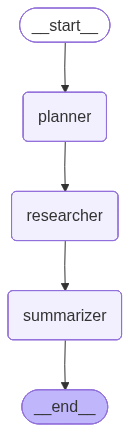

In [13]:
# ==========================================
# Visualize Workflow
# ==========================================

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# ==========================================
# Observe State Evolution
# ==========================================

result = graph.invoke({"user_query": "What is Agentic AI?"})

print("\n" + "="*60)
print("FINAL STATE")
print("="*60)

for key, value in result.items():
    print(f"\n{key}:")
    if isinstance(value, list):
        print(value)
    else:
        print(value)


--- Planner Node Executed ---

--- Researcher Node Executed ---

--- Summarizer Node Executed ---

FINAL STATE

user_query:
What is Agentic AI?

keywords:
['What is Agentic AI?', 'AI', 'Research']

research_notes:
Agentic AI refers to artificial intelligence systems designed with a degree of autonomy, enabling them to make decisions and take actions independently. This concept is a significant focus in AI research, as it explores the potential for AI to operate with a level of agency similar to that of humans. By integrating advanced algorithms and machine learning techniques, Agentic AI aims to enhance the decision-making capabilities of AI systems, allowing them to adapt to dynamic environments and complex scenarios. Researchers are particularly interested in understanding the implications of such autonomy, including ethical considerations and the potential impact on various industries. As AI continues to evolve, the development of Agentic AI represents a crucial step towards creati

In [ ]:
# ==========================================
# Notebook 2 Recap
# ==========================================

print("""
Key Learnings ->

1. Multiple nodes can be connected sequentially.
2. Each node can read data written by previous nodes.
3. State acts as shared memory.
4. Nodes only return updates.
5. LangGraph automatically merges state updates.
6. Sequential workflows are the foundation of
   most AI pipelines.
""")


Key Learnings

1. Multiple nodes can be connected sequentially.

2. Each node can read data written by previous nodes.

3. State acts as shared memory.

4. Nodes only return updates.

5. LangGraph automatically merges state updates.

6. Sequential workflows are the foundation of
   most AI pipelines.

